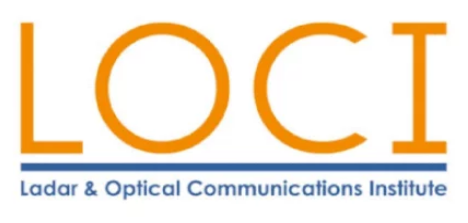

# Function: Lidar - Photons Returned 

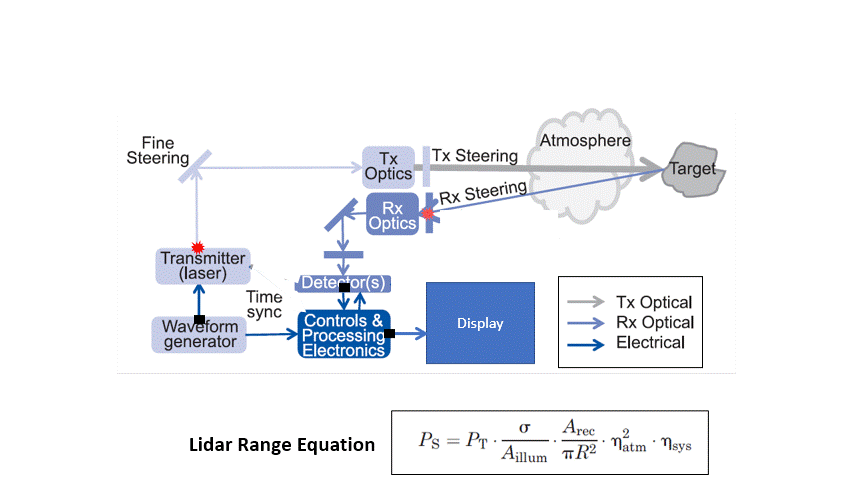

In [1]:
#Importing libraries
%matplotlib inline
#%matplotlib notebook
import os
import math
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, Layout, widgets
import matplotlib.image as mpimg

#setting constants
#HV = 5000  #Human Visibility (m) number
#EPP = 0.2   #Energy per pulse (mjoule) number
#RAD = 25   #Receiver Aperture Diameter (mm) number
NUMPT = 500 #number of points on graph
RHL = 100000 # Range High log
RLL = 1  # Range Low Log

    
 
os.chdir(r'C:\Users\Owner\Documents\Ryan\LOCI 2021')

file1 = open('FitData.csv', 'r') 
COE = np.loadtxt('FitData.csv', delimiter=',')
file1.close
size=COE.shape

#print(size) 

def datafunc (REF, HV, EPP, RAD, Atmosphere, Aerosol, Range_Low, Range_High):

    skip = False #makes the code skip if limit is not met   
    
    #input limits
    if (REF < 0) :
        skip = True
    if (REF > 1.0) :
        skip = True
    if (EPP <= 0) : 
        skip = True
    if (HV <= 0) : 
        skip = True
    if (RAD <= 0) : 
        skip = True
    
    if skip == True :
        print ('Invalid Inputs')
        
    else :    

        #Modtran atmosphere call
            if Atmosphere == "Standard":
                if Aerosol == "23km":
                    mtnum = 3
                elif Aerosol == "5km":
                    mtnum = 4
                elif Aerosol == "3km":
                    mtnum = 5
            if Atmosphere == "Tropical":
                if Aerosol == "23km":
                    mtnum = 0
                elif Aerosol == "5km":
                    mtnum = 1
                elif Aerosol == "3km":
                    mtnum = 2
            if Atmosphere == "Winter":
                if Aerosol == "23km":
                    mtnum = 6
                elif Aerosol == "5km":
                    mtnum = 7
                elif Aerosol == "3km": 
                    mtnum = 8
 
            #print (mtnum)
    
            OWTL= COE[mtnum,0]*np.exp(COE[mtnum,1]*(Range_Low/1000)) + COE[mtnum,2]
            OWTH= COE[mtnum,0]*np.exp(COE[mtnum,1]*(Range_High/1000)) + COE[mtnum,2]
            #print(COE[mtnum,0],COE[mtnum,1],COE[mtnum,2])
            #print(Range_Low,OWTL)
            #print(Range_High,OWTH)
            
            
            #  Log Calculations 
            B55 = -(math.log(0.05))/HV #idk find out
            B155 = B55*(1.55/0.55)**-(0.1428*1.55-0.0947) #idk find out
            NUMPTL = NUMPT*10
            SSL = (RHL - RLL)/(NUMPTL)
            #print('start loop')
            PRListL = np.zeros(NUMPTL)
            PRListt = []
            IRListL = np.zeros(NUMPTL)
            IRListt = []
            for cnt in range (0,NUMPTL) : 
                IRTEMPL = RLL + cnt*SSL
                #OWTL = math.exp(-B155*IRTEMPL)  #One Way Transmission
                TWTL = OWTL**2 #Two Way Transmission
                PRL = EPP*0.001*(REF/64**2)*((0.001*RAD)/(IRTEMPL)**2*(0.00000155/(300000000*6.64E-34)*TWTL*0.6))   #number of photons received from a 10% reflective object
                #print('Photons Returned = ', PR,'IRTEMP = ',IRTEMP, 'count = ',cnt)
                PRListL[cnt] = PRL
                IRListL[cnt] = IRTEMPL
                if IRTEMPL > Range_Low :
                    if IRTEMPL < Range_High:
                        PRListt.append(PRL)
                        IRListt.append(IRTEMPL)
                cnt +=1
                
            # linear calculations
            B55 = -(math.log(0.05))/HV #idk find out
            B155 = B55*(1.55/0.55)**-(0.1428*1.55-0.0947) #idk find out
            SS = (Range_High - Range_Low)/NUMPT
            #print('start loop')
            PRList = np.zeros(NUMPT)
            IRList = np.zeros(NUMPT)
            for cnt in range (0,NUMPT) : 
                IRTEMP = Range_Low + cnt*SS
                OWT = math.exp(-B155*IRTEMP)  #One Way Transmission
                TWT = OWT**2 #Two Way Transmission
                PR = EPP*0.001*(REF/64**2)*((0.001*RAD)/(IRTEMP)**2*(0.00000155/(300000000*6.64E-34)*TWT*0.6))   #number of photons received from a 10% reflective object
                #print('Photons Returned = ', PR,'IRTEMP = ',IRTEMP, 'count = ',cnt)
                PRList[cnt] = PR 
                IRList[cnt] = IRTEMP
                cnt +=1
               # print('now n=',cnt , NUMPT)
    
            PRLRL="{:.2e}".format(PRList[0])
            PRLRH="{:.2e}".format(PRList[NUMPT-1])
            ## "Calculated Results" section heading and text results
            CalcResults = widgets.HTML(value = "<br><p style='font-size:16pt'><b>Calculated Results:</b></p>"
            "<b>Photons Returned:</b> <i>"  + str(PRLRL) + "</i><b> at inner range: <i></b>" + str(round(Range_Low))  + "</i><b> (m) </b></p><r>" 
            "<b>Photons Returned:</b> <i>"  + str(PRLRH) + "</i><b> at outer range:  <i></b>" + str(round(Range_High))  + "</i><b> (m) "                          
            )
        
            display(CalcResults) 
                
            #linear plot
            plt.style.use('classic')
            fig = plt.figure(figsize=(12,10))
            ax1 = fig.add_subplot(2, 1, 2)
            ax1.plot(IRList, PRList,color='slateblue',linewidth=2)
            plt.axis([Range_Low, Range_High,0,max(PRList)])
            #plt.title('Photons Returned')
            plt.ylabel('# of Photons Returned')
            plt.xlabel('Range - M')
            
            #add tickmarks
            major_xticks = np.arange(Range_Low, Range_High, (Range_High - Range_Low)/10)
            minor_xticks = np.arange(Range_Low, Range_High, (Range_High - Range_Low)/50)
            ax1.set_xticks(major_xticks)
            ax1.set_xticks(minor_xticks, minor=True)
            # And a corresponding grid
            ax1.grid(which='minor', alpha=0.25)
            ax1.grid(which='major', alpha=0.75)
            
            #log Plot
            plt.style.use('dark_background')
            #fig = plt.figure(figsize=(14,9))
            ax2 = fig.add_subplot(2, 1, 1)
            ax2.plot(IRListL, PRListL,':r',linewidth=3)
            ax2.plot(IRListt, PRListt,'b',linewidth=4)
            #plt.axis([Range_Low, Range_High,0,max(PRList)])
            plt.title('Photons Returned',color='black')
            plt.ylabel('# of Photons Returned')
            #plt.xlabel('Range - M')
            ax2.set_xscale('log')
            ax2.set_yscale('log')
            plt.axis([RLL, RHL,min(PRListL),10*max(PRListL)])
            plt.grid(True)


style1 = {'description_width': 'initial'} 
interact(datafunc,
             REF = widgets.FloatText(value=0.1,min = 0, max=1, step=0.01, description = 'η System - Reflection (%)',style=style1),
             HV = widgets.FloatText(value=5000,min = 0.001, step=500, description = ' η Atmos - Human Visibility(m)',style=style1),
             EPP = widgets.FloatText(value=0.5, min = 0.001, step=0.05, description = 'Power Trans - Energy Per Pulse(mJ)',style=style1),
             RAD = widgets.FloatText(value=50,min = 0.001, step=1, description = 'Receiver Aperture Diameter(mm)',style=style1),
             Atmosphere=["Standard","Tropical","Winter"],
             Aerosol=["23km","5km","3km"],
             Range_Low = widgets.FloatSlider(value=3000, min=RLL, max=RHL, step=10, continuous_update=False,layout=Layout(width='840px')),
             Range_High = widgets.FloatSlider(value=10000, min=RLL, max=RHL, step=10, continuous_update=False,layout=Layout(width='840px')), 
             );    
    
 
         
         
        




NameError: name 'CO' is not defined

## Code By Ryan Devitt
### Figure credit: Paul McManamon, Field Guide to Lidar, SPIE Press, p. 1 (2015) [doi: 10.1117/3.2186106].